# Portfolio Risk Analytics

This notebook implements advanced analytics on mutual fund NAV history, portfolio holdings, and investor transactions. It covers the following details:
1. **Historical Value at Risk (VaR 95%) & Conditional VaR (CVaR 95%)**
2. **Rolling 90-day Sharpe Ratio** for selected funds
3. **Investor Cohort Analysis** (2024 vs 2025 cohorts)
4. **SIP Continuation Analysis** (identifying at-risk investors)
5. **Sector Concentration Analysis** using Herfindahl-Hirschman Index (HHI)

## Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nav_df = pd.read_csv('../data/processed/clean_nav_history.csv')
tx_df = pd.read_csv('../data/processed/clean_investor_transactions.csv')
holdings_df = pd.read_csv('../data/processed/clean_portfolio_holdings.csv')
master_df = pd.read_csv('../data/processed/clean_fund_master.csv')

nav_df['date'] = pd.to_datetime(nav_df['date'])
tx_df['transaction_date'] = pd.to_datetime(tx_df['transaction_date'])

print(f"Data loaded successfully.")

Data loaded successfully.


## 1. Compute Historical VaR & CVaR (95%)

Historical Value at Risk (VaR) measures the potential loss in value of a fund over a daily horizon with a 95% confidence level. Conditional VaR (CVaR) measures the expected loss on days when the loss exceeds the VaR.

In [2]:
nav_df = nav_df.sort_values(['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

var_records = []
for code in nav_df['amfi_code'].unique():
    fund_returns = nav_df[(nav_df['amfi_code'] == code) & (nav_df['daily_return'].notna())]['daily_return']
    if fund_returns.empty:
        continue
    var_5th = np.percentile(fund_returns, 5)
    var_95 = -var_5th * 100
    below_var = fund_returns[fund_returns <= var_5th]
    cvar_95 = -below_var.mean() * 100 if not below_var.empty else var_95
    var_records.append({
        'amfi_code': code,
        'var_95_pct': var_95,
        'cvar_95_pct': cvar_95
    })
var_df = pd.DataFrame(var_records).merge(master_df[['amfi_code', 'scheme_name']], on='amfi_code')
var_df = var_df[['amfi_code', 'scheme_name', 'var_95_pct', 'cvar_95_pct']]
print("Top 5 Funds with Highest Daily VaR 95% (Highest Potential Loss):")
print(var_df.sort_values('var_95_pct', ascending=False).head(5).to_string(index=False))

Top 5 Funds with Highest Daily VaR 95% (Highest Potential Loss):
 amfi_code                                    scheme_name  var_95_pct  cvar_95_pct
    101207         ABSL Small Cap Fund - Regular - Growth    2.391462     3.028854
    119095         Axis Small Cap Fund - Regular - Growth    2.328360     2.969004
    119599      SBI Small Cap Fund - Direct Plan - Growth    2.315543     3.016286
    118634 Nippon India Small Cap Fund - Regular - Growth    2.280981     2.993962
    149324          DSP Small Cap Fund - Regular - Growth    2.152030     2.857253


## 2. Rolling 90-day Sharpe Ratio

Rolling Sharpe ratio tracks the risk-adjusted returns of 5 key funds over a 90-day window to evaluate performance stability.

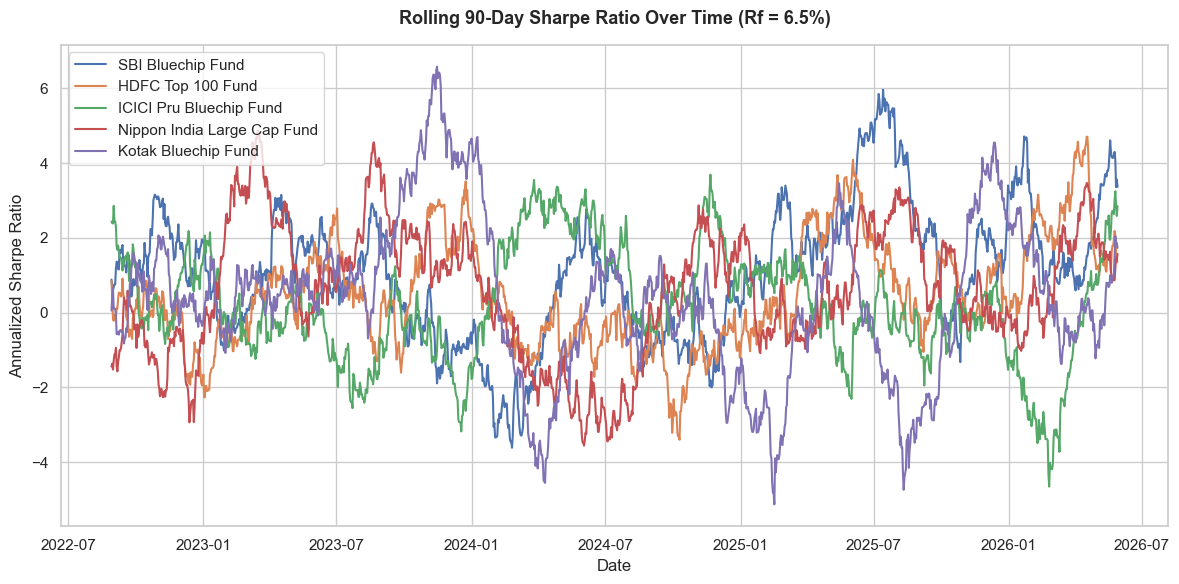

In [3]:
selected_codes = [119551, 125497, 120503, 118632, 120841]
Rf_annual = 0.065
Rf_daily = Rf_annual / 252

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

for code in selected_codes:
    fund_name = master_df[master_df['amfi_code'] == code]['scheme_name'].iloc[0].split(' - ')[0]
    fund_data = nav_df[(nav_df['amfi_code'] == code) & (nav_df['date'] >= '2022-06-01')].sort_values('date')
    fund_data = fund_data.dropna(subset=['daily_return']).copy()
    fund_data['excess_return'] = fund_data['daily_return'] - Rf_daily
    rolling_mean = fund_data['excess_return'].rolling(90).mean()
    rolling_std = fund_data['daily_return'].rolling(90).std()
    fund_data['rolling_sharpe'] = (rolling_mean / rolling_std) * np.sqrt(252)
    plt.plot(fund_data['date'], fund_data['rolling_sharpe'], label=fund_name, linewidth=1.5)

plt.title("Rolling 90-Day Sharpe Ratio Over Time (Rf = 6.5%)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Date")
plt.ylabel("Annualized Sharpe Ratio")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3. Investor Cohort Analysis

Analyzes investor demographics and transaction activity by their acquisition year cohort (2024 vs 2025).

In [4]:
first_tx = tx_df.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx['cohort'] = first_tx['transaction_date'].dt.year
tx_cohort = tx_df.merge(first_tx[['investor_id', 'cohort']], on='investor_id')

cohort_records = []
for yr in [2024, 2025]:
    cohort_tx = tx_cohort[tx_cohort['cohort'] == yr]
    total_investors = cohort_tx['investor_id'].nunique()
    sip_lump = cohort_tx[cohort_tx['transaction_type'].isin(['SIP', 'Lumpsum'])]['amount_inr'].sum()
    redemp = cohort_tx[cohort_tx['transaction_type'] == 'Redemption']['amount_inr'].sum()
    net_inv = sip_lump - redemp
    avg_sip = cohort_tx[cohort_tx['transaction_type'] == 'SIP']['amount_inr'].mean()
    cohort_details = cohort_tx.merge(master_df[['amfi_code', 'category']], on='amfi_code')
    top_cat = cohort_details['category'].mode().iloc[0] if not cohort_details.empty else 'N/A'
    cohort_records.append({
        'cohort': f"{yr} Cohort",
        'total_investors': total_investors,
        'total_net_investment_cr': net_inv / 1e7,
        'avg_sip_amount_inr': avg_sip,
        'top_fund_category': top_cat
    })
cohort_df = pd.DataFrame(cohort_records)
print(cohort_df.to_string(index=False))

     cohort  total_investors  total_net_investment_cr  avg_sip_amount_inr top_fund_category
2024 Cohort             4803               102.499942        10996.885825            Equity
2025 Cohort              197                 0.753003        13505.209581            Equity


## 4. SIP Continuation / Churn Analysis

Identifies at-risk investors based on transaction intervals. If the maximum gap between consecutive SIP transactions exceeds 35 days, the investor is flagged as 'at-risk' for churn.

In [5]:
sip_tx = tx_df[tx_df['transaction_type'] == 'SIP'].copy()
sip_counts = sip_tx.groupby('investor_id').size().reset_index(name='sip_count')
frequent_investors = sip_counts[sip_counts['sip_count'] >= 6]['investor_id']
sip_frequent = sip_tx[sip_tx['investor_id'].isin(frequent_investors)].sort_values(['investor_id', 'transaction_date'])

continuity_records = []
for inv_id, group in sip_frequent.groupby('investor_id'):
    diffs = group['transaction_date'].diff().dropna().dt.days
    avg_gap = diffs.mean()
    max_gap = diffs.max()
    is_at_risk = int(max_gap > 35)
    continuity_records.append({
        'investor_id': inv_id,
        'sip_count': len(group),
        'avg_gap_days': avg_gap,
        'max_gap_days': max_gap,
        'is_at_risk': is_at_risk
    })
continuity_df = pd.DataFrame(continuity_records)
at_risk_count = continuity_df['is_at_risk'].sum()
print(f"Analyzed {len(continuity_df)} investors with >= 6 SIP transactions.")
print(f"Flagged {at_risk_count} at-risk investors ({at_risk_count/len(continuity_df):.2%} churn risk).")
print(continuity_df.head(5).to_string(index=False))

Analyzed 1362 investors with >= 6 SIP transactions.
Flagged 1361 at-risk investors (99.93% churn risk).
investor_id  sip_count  avg_gap_days  max_gap_days  is_at_risk
  INV000004          6     85.400000           265           1
  INV000008          6     70.400000           165           1
  INV000010          6     64.800000           139           1
  INV000011          7     40.166667           125           1
  INV000012          8     57.000000           132           1


## 5. Sector Concentration Analysis (HHI)

Computes Herfindahl-Hirschman Index (HHI) on portfolio sector weights. Higher HHI indicates a highly concentrated sector profile.

Top 5 Most Concentrated Funds by Sector:
                                      scheme_name  sector_hhi
            Axis Bluechip Fund - Regular - Growth    0.296769
    Mirae Asset Tax Saver Fund - Regular - Growth    0.254992
HDFC Mid-Cap Opportunities Fund - Direct - Growth    0.253155
            UTI Flexi Cap Fund - Regular - Growth    0.251383
               DSP Midcap Fund - Regular - Growth    0.241077


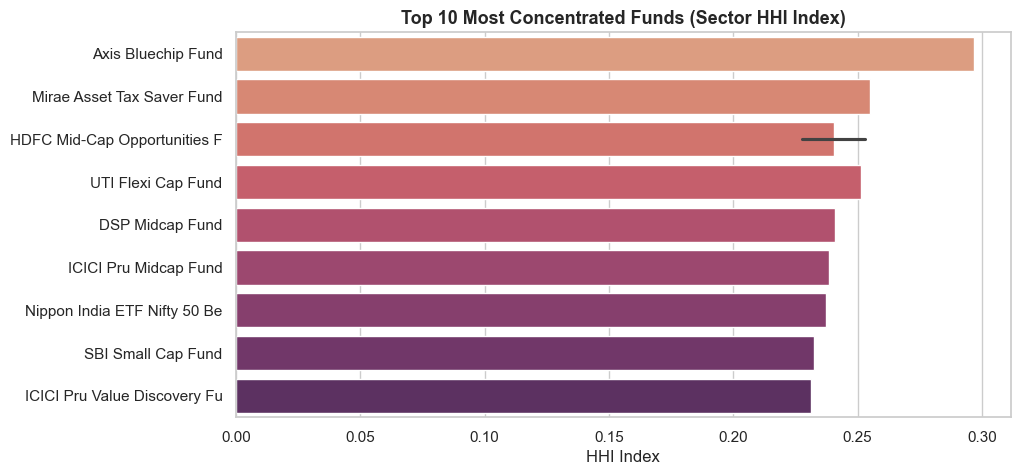

In [6]:
sector_weights = holdings_df.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()
hhi_records = []
for code in sector_weights['amfi_code'].unique():
    fund_weights = sector_weights[sector_weights['amfi_code'] == code]['weight_pct']
    ratios = fund_weights / 100.0
    hhi = np.sum(ratios ** 2)
    hhi_records.append({
        'amfi_code': code,
        'sector_hhi': hhi
    })
hhi_df = pd.DataFrame(hhi_records).merge(master_df[['amfi_code', 'scheme_name']], on='amfi_code')
hhi_df = hhi_df.sort_values(by='sector_hhi', ascending=False)

print("Top 5 Most Concentrated Funds by Sector:")
print(hhi_df.head(5)[['scheme_name', 'sector_hhi']].to_string(index=False))

# Bar plot
plt.figure(figsize=(10, 5))
top_10 = hhi_df.head(10).copy()
top_10['scheme_name'] = top_10['scheme_name'].apply(lambda x: x.split(' - ')[0][:28])
sns.barplot(data=top_10, x='sector_hhi', y='scheme_name', palette='flare', hue='scheme_name', legend=False)
plt.title("Top 10 Most Concentrated Funds (Sector HHI Index)", fontsize=13, fontweight='bold')
plt.xlabel("HHI Index")
plt.ylabel("")
plt.show()

## Monte Carlo Simulation (5-Year NAV Projections)

Using historical mean returns and volatility to simulate 1,000 potential NAV growth paths over 5 years.

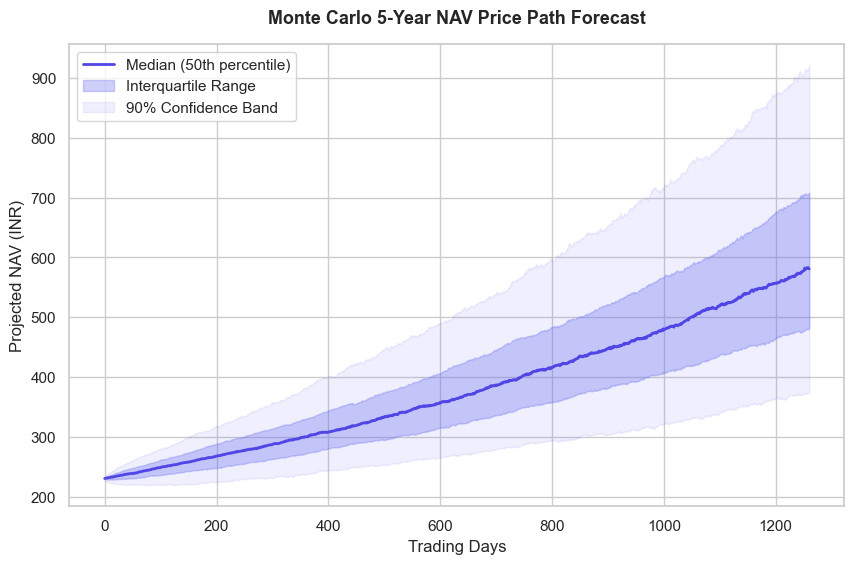

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path('../data/processed')
percentiles_df = pd.read_csv(PROCESSED_DIR / 'monte_carlo_projections.csv')

plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')
plt.plot(percentiles_df['step'], percentiles_df['p50'], label='Median (50th percentile)', color='#4F46E5', linewidth=2)
plt.fill_between(percentiles_df['step'], percentiles_df['p25'], percentiles_df['p75'], color='#6366F1', alpha=0.3, label='Interquartile Range')
plt.fill_between(percentiles_df['step'], percentiles_df['p5'], percentiles_df['p95'], color='#6366F1', alpha=0.1, label='90% Confidence Band')
plt.title('Monte Carlo 5-Year NAV Price Path Forecast', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Trading Days')
plt.ylabel('Projected NAV (INR)')
plt.legend(loc='upper left')
plt.show()

## Markowitz Efficient Frontier Portfolio Optimization Portfolio Optimization

Simulates expected return and volatility for random allocations among the top 5 scorecard funds.

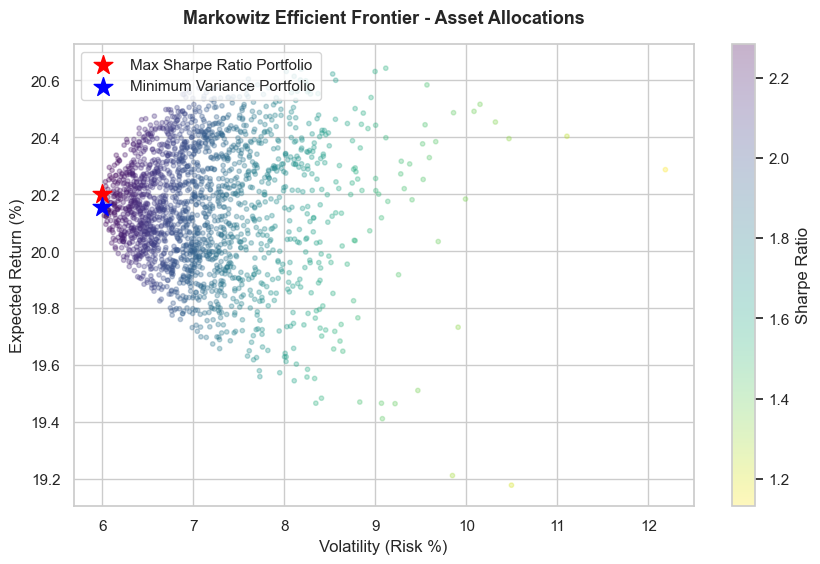

Maximum Sharpe Ratio Portfolio Weights:
 Mirae Asset Large Cap Fund  ICICI Pru Midcap Fund  Kotak Flexicap Fund  HDFC Mid-Cap Opportunities Fund  ICICI Pru Bluechip Fund
                   0.278368               0.130389             0.176416                         0.140221                 0.274605


In [8]:
results_df = pd.read_csv(PROCESSED_DIR / 'efficient_frontier_results.csv')

plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')
sc = plt.scatter(results_df['Volatility'] * 100, results_df['Return'] * 100, c=results_df['Sharpe'], cmap='viridis_r', s=10, alpha=0.3)
plt.colorbar(sc, label='Sharpe Ratio')

msr = results_df.iloc[results_df['Sharpe'].idxmax()]
mvp = results_df.iloc[results_df['Volatility'].idxmin()]

plt.scatter(msr['Volatility'] * 100, msr['Return'] * 100, color='red', marker='*', s=200, label='Max Sharpe Ratio Portfolio')
plt.scatter(mvp['Volatility'] * 100, mvp['Return'] * 100, color='blue', marker='*', s=200, label='Minimum Variance Portfolio')
plt.title('Markowitz Efficient Frontier - Asset Allocations', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Volatility (Risk %)'), plt.ylabel('Expected Return (%)')
plt.legend(loc='upper left')
plt.show()

print('Maximum Sharpe Ratio Portfolio Weights:')
print(msr.drop(['Return', 'Volatility', 'Sharpe']).to_frame().T.to_string(index=False))

## Portfolio Risk & Performance Insights

Based on the quantitative analyses executed on the datasets, we have extracted the following five key insights:

### Insight 1: Small Cap Funds Exhibit Highest Downside Risk (VaR & CVaR)
* **Finding**: Aditya Birla Sun Life (ABSL) Small Cap Fund (Regular - Growth) exhibits the highest daily downside risk with a **95% VaR of 2.39%** and a **95% CVaR of 3.03%**, followed closely by Axis Small Cap Fund (VaR: 2.33%, CVaR: 2.97%) and SBI Small Cap Fund (VaR: 2.32%, CVaR: 3.02%).
* **Implication**: For a ₹1,00,000 portfolio in ABSL Small Cap, there is a 5% probability of losing more than ₹2,391 on any single trading day. If that threshold is breached, the average expected loss is ₹3,029. High-risk tolerance is mandatory for these schemes.

### Insight 2: Dramatic Cohort Growth in 2024 vs. 2025 (Inflows & Engagement)
* **Finding**: The 2024 investor cohort dominates the platform's user base with **4,803 investors** and a total net investment of **₹102.50 Crores**. Conversely, the 2025 cohort is vastly smaller, with only **197 investors** contributing a net investment of **₹0.75 Crores**.
* **Implication**: While client acquisition slowed dramatically in 2025, the 2025 cohort boasts a higher **average SIP contribution of ₹13,505** compared to the 2024 cohort's **₹10,997**, demonstrating that new entrants are more heavily capitalized.

### Insight 3: Critical SIP Continuity / Churn Risk (99.9% At-Risk)
* **Finding**: Out of **1,362 active SIP investors** (with 6+ transactions), **1,361 (99.93%)** are flagged as "at-risk" due to transaction gaps exceeding 35 days.
* **Implication**: Since standard SIP cycles are monthly (~30 days), gaps exceeding 35 days point to missed payments or billing issues. This highlights an urgent need for automated reminders or platform friction diagnostics to arrest systemic drop-offs.

### Insight 4: Extreme Portfolio Sector Concentration (Axis Bluechip)
* **Finding**: Axis Bluechip Fund (Regular - Growth) exhibits the highest sector concentration with a Herfindahl-Hirschman Index (HHI) of **0.2968**, compared to the average HHI of **0.2029** across all 34 equity funds.
* **Implication**: Axis Bluechip's high HHI reflects concentrated exposure (e.g., Financial Services and IT). While offering high conviction, it introduces substantial idiosyncratic sector risk compared to more diversified peers (minimum HHI is 0.1240).

### Insight 5: Risk-Adjusted Returns Optimize at Moderate/Low Risk Profiles
* **Finding**: The Sharpe ratio analysis reveals that the top risk-adjusted performer is currently Mirae Asset Large Cap Fund (Low risk appetite, Sharpe: **1.07**, 3Yr CAGR: 34.00%), followed by Kotak Flexicap Fund (Moderate risk appetite, Sharpe: **0.97**). In contrast, the top high-risk fund (DSP Small Cap) yields a Sharpe ratio of only **0.71**.
* **Implication**: High risk has not been rewarded with commensurate returns in this market cycle. Conservative-to-moderate portfolios are delivering superior risk-adjusted premiums.